# **Install & Import Libraries**

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load all cleaned datasets
activity   = pd.read_csv("merged_daily_activity_sleep.csv")
hourly     = pd.read_csv("hourlySteps_cleaned.csv")
sleep      = pd.read_csv("sleepDay_final.csv")
weight     = pd.read_csv("weightLog_final.csv")
heartrate  = pd.read_csv("heartrate_cleaned.csv")

# Convert date columns to datetime format
activity['ActivityDate']      = pd.to_datetime(activity['ActivityDate'])
hourly['ActivityDateTime']    = pd.to_datetime(hourly['ActivityDateTime'], 
                                               infer_datetime_format=True)
sleep['ActivityDateTime']     = pd.to_datetime(sleep['ActivityDateTime'],  
                                               infer_datetime_format=True)

# Create extra columns needed for analysis
activity['SleepHours']        = activity['TotalMinutesAsleep'] / 60
activity['SedentaryHours']    = activity['SedentaryMinutes'] / 60
activity['DayType']           = activity['ActivityDate'].dt.dayofweek.apply(
                                    lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Preview data
print("=== Data Loaded Successfully ===")
print(f"Activity rows  : {len(activity)}")
print(f"Hourly rows    : {len(hourly)}")
print(f"Sleep rows     : {len(sleep)}")
print(f"Weight rows    : {len(weight)}")
print(f"Heartrate rows : {len(heartrate)}")

C:\Users\Harika challa\AppData\Local\Temp\ipykernel_2696\2284993344.py:18: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  hourly['ActivityDateTime']    = pd.to_datetime(hourly['ActivityDateTime'],
C:\Users\Harika challa\AppData\Local\Temp\ipykernel_2696\2284993344.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly['ActivityDateTime']    = pd.to_datetime(hourly['ActivityDateTime'],


=== Data Loaded Successfully ===
Activity rows  : 863
Hourly rows    : 22099
Sleep rows     : 410
Weight rows    : 67
Heartrate rows : 2483658


C:\Users\Harika challa\AppData\Local\Temp\ipykernel_2696\2284993344.py:20: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  sleep['ActivityDateTime']     = pd.to_datetime(sleep['ActivityDateTime'],
C:\Users\Harika challa\AppData\Local\Temp\ipykernel_2696\2284993344.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep['ActivityDateTime']     = pd.to_datetime(sleep['ActivityDateTime'],


In [29]:
activity.head()

,Id,ActivityDate,TotalSteps,Calories,SedentaryMinutes,LightlyActiveMinutes,FairlyActiveMinutes,VeryActiveMinutes,TotalActiveMinutes,TotalMinutesAsleep,TotalTimeInBed,SleepDeficitMinutes,ActivityCategory,SleepHours,SedentaryHours,DayType
0,1503960366,2016-04-12,13162,1985,728,328,13,25,366,327,346,153,Lightly Active,5.450000,12.133333,Weekday
1,1503960366,2016-04-13,10735,1797,776,217,19,21,257,384,407,96,Lightly Active,6.400000,12.933333,Weekday
2,1503960366,2016-04-14,10460,1776,1218,181,11,30,222,0,0,480,Very Active,0.000000,20.300000,Weekday
3,1503960366,2016-04-15,9762,1745,726,209,34,29,272,412,442,68,Fairly Active,6.866667,12.100000,Weekday
4,1503960366,2016-04-16,12669,1863,773,221,10,36,267,340,367,140,Very Active,5.666667,12.883333,Weekend


In [30]:
hourly.head()

,Id,ActivityDateTime,StepTotal
0,1503960366,2016-04-12 00:00:00,373
1,1503960366,2016-04-12 01:00:00,160
2,1503960366,2016-04-12 02:00:00,151
3,1503960366,2016-04-12 03:00:00,0
4,1503960366,2016-04-12 04:00:00,0


In [31]:
sleep.head()

,Id,ActivityDateTime,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,1,327,346
1,1503960366,2016-04-13,2,384,407
2,1503960366,2016-04-15,1,412,442
3,1503960366,2016-04-16,2,340,367
4,1503960366,2016-04-17,1,700,712


In [32]:
weight.head()

,Id,ActivityDateTime,WeightKg,WeightPounds,BMI,IsManualReport,LogId
0,1503960366,2016-05-02 11:59:59 PM,52.599998,115.963147,22.650000,True,1462233599000
1,1503960366,2016-05-03 11:59:59 PM,52.599998,115.963147,22.650000,True,1462319999000
2,1927972279,2016-04-13 1:08:52 AM,133.500000,294.317120,47.540001,False,1460509732000
3,2873212765,2016-04-21 11:59:59 PM,56.700001,125.002104,21.450001,True,1461283199000
4,2873212765,2016-05-12 11:59:59 PM,57.299999,126.324875,21.690001,True,1463097599000


In [33]:
heartrate.head()

,Id,ActivityDateTime,HeartRate
0,2022484408,2016-04-12 7:21:00 AM,97
1,2022484408,2016-04-12 7:21:05 AM,102
2,2022484408,2016-04-12 7:21:10 AM,105
3,2022484408,2016-04-12 7:21:20 AM,103
4,2022484408,2016-04-12 7:21:25 AM,101


# Analysis-1 — Activity Distribution (% Sedentary vs Active)

=== Activity Distribution ===
ActivityCategory
Lightly Active    58.3
Very Active       29.2
Fairly Active      8.6
Sedentary          3.9
Name: proportion, dtype: float64


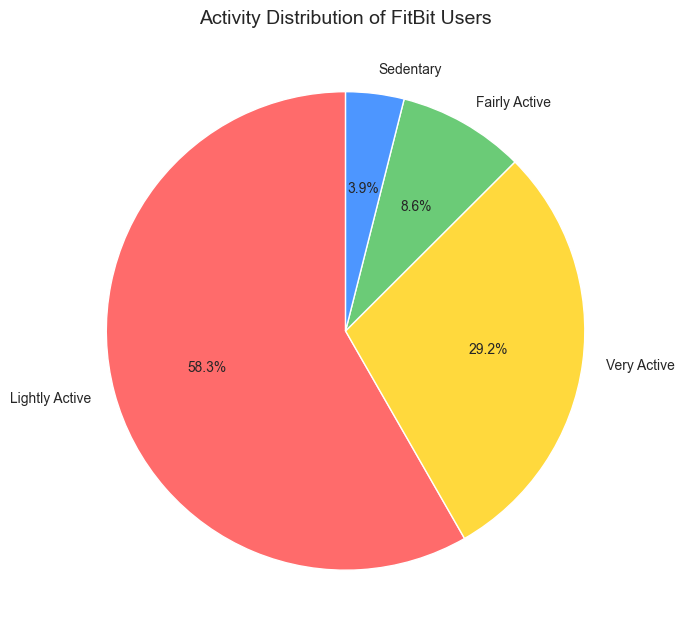

In [34]:
# Count how many days fall into each activity category
category_counts = activity['ActivityCategory'].value_counts()
category_pct    = activity['ActivityCategory'].value_counts(normalize=True) * 100

print("=== Activity Distribution ===")
print(category_pct.round(1))

# Pie chart
colors = ['#ff6b6b', '#ffd93d', '#6bcb77', '#4d96ff']

plt.figure(figsize=(7, 7))
plt.pie(category_counts,
        labels=category_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
plt.title('Activity Distribution of FitBit Users', fontsize=14)
plt.tight_layout()
plt.savefig('activity_distribution.png', dpi=150)
plt.show()

# Analysis-2 — Steps vs Calories Correlation

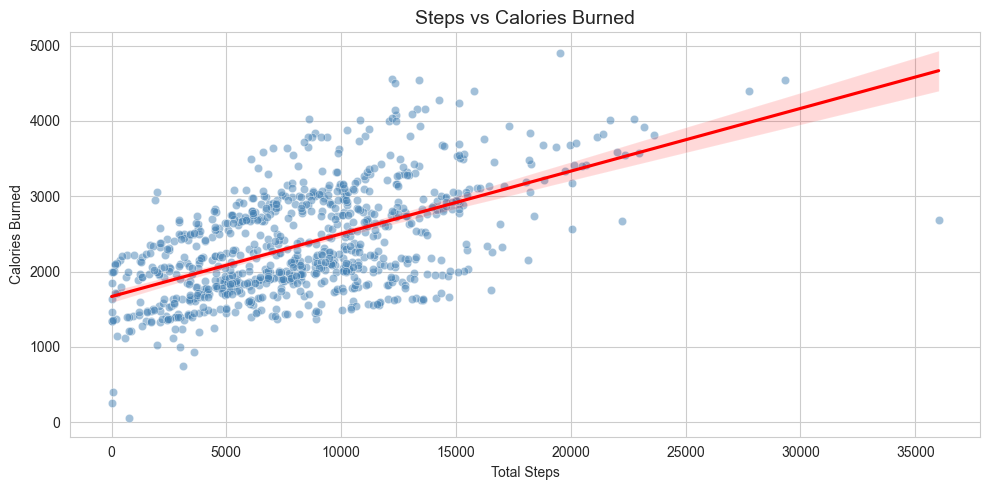

Correlation between Steps and Calories: 0.56
Interpretation: 0.0 = no relation | 1.0 = perfect relation


In [35]:
# Filter out 0 step rows for cleaner correlation
activity_filtered = activity[activity['TotalSteps'] > 0]

plt.figure()
sns.scatterplot(data=activity_filtered,
                x='TotalSteps',
                y='Calories',
                alpha=0.5,
                color='steelblue')
sns.regplot(data=activity_filtered,
            x='TotalSteps',
            y='Calories',
            scatter=False,
            color='red')
plt.title('Steps vs Calories Burned', fontsize=14)
plt.xlabel('Total Steps')
plt.ylabel('Calories Burned')
plt.tight_layout()
plt.savefig('steps_vs_calories.png', dpi=150)
plt.show()

# Print correlation value
corr = activity_filtered['TotalSteps'].corr(activity_filtered['Calories'])
print(f"Correlation between Steps and Calories: {corr:.2f}")
print("Interpretation: 0.0 = no relation | 1.0 = perfect relation")

# Analysis-3 — Sleep Patterns

Average Sleep Duration  : 7.0 hours
Days under 7 hrs sleep  : 181 out of 410 (44.1%)


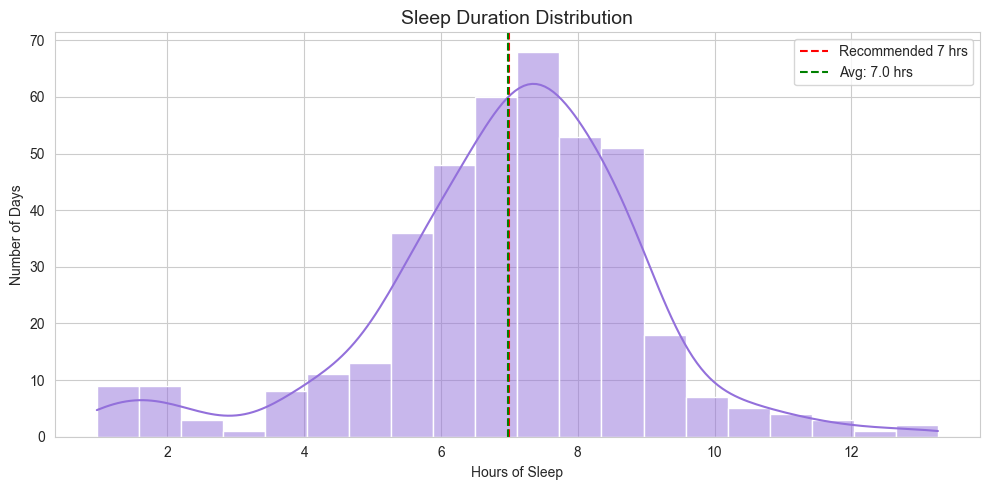

In [36]:
# Filter only days where sleep was actually logged
sleep_logged = activity[activity['TotalMinutesAsleep'] > 0].copy()

avg_sleep = sleep_logged['SleepHours'].mean()
under_7   = (sleep_logged['SleepHours'] < 7).sum()
total     = len(sleep_logged)

print(f"Average Sleep Duration  : {avg_sleep:.1f} hours")
print(f"Days under 7 hrs sleep  : {under_7} out of {total} ({(under_7/total*100):.1f}%)")

plt.figure()
sns.histplot(sleep_logged['SleepHours'], bins=20, color='mediumpurple', kde=True)
plt.axvline(x=7,         color='red',   linestyle='--', label='Recommended 7 hrs')
plt.axvline(x=avg_sleep, color='green', linestyle='--', label=f'Avg: {avg_sleep:.1f} hrs')
plt.title('Sleep Duration Distribution', fontsize=14)
plt.xlabel('Hours of Sleep')
plt.ylabel('Number of Days')
plt.legend()
plt.tight_layout()
plt.savefig('sleep_patterns.png', dpi=150)
plt.show()


# Analysis-4 — Peak Activity Hours Heatmap

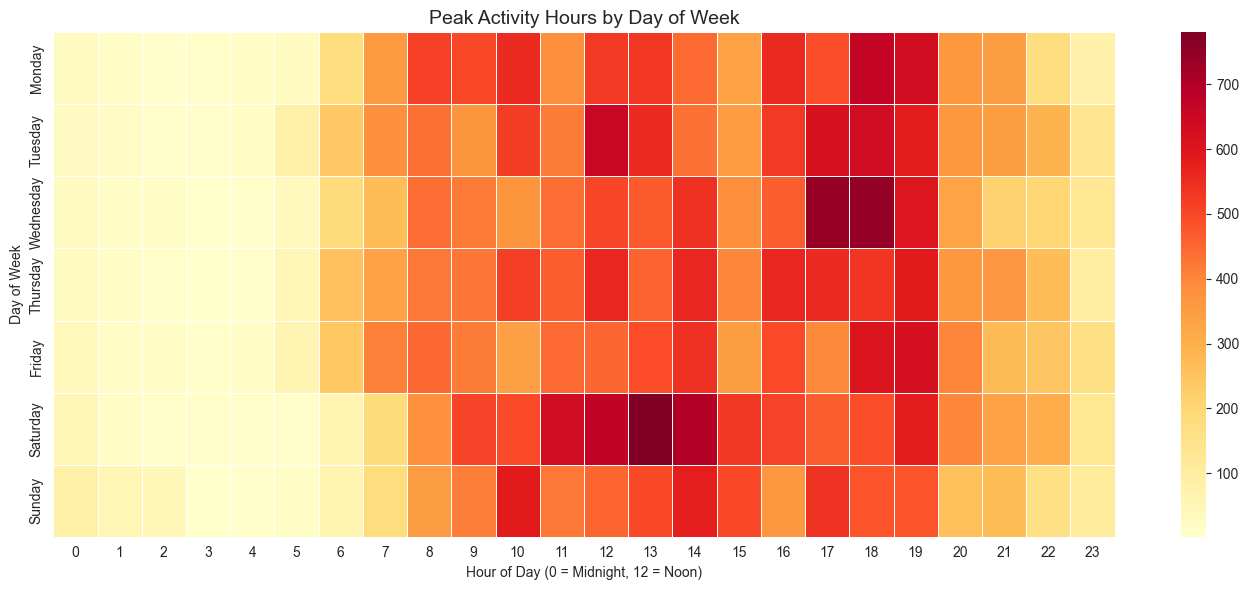

In [37]:
# Extract hour and day of week from ActivityDateTime
hourly['Hour']      = hourly['ActivityDateTime'].dt.hour
hourly['DayOfWeek'] = hourly['ActivityDateTime'].dt.day_name()

# Calculate average steps per hour per day
heatmap_data = hourly.groupby(['DayOfWeek', 'Hour'])['StepTotal'].mean().unstack()

# Order days correctly Mon to Sun
day_order    = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data,
            cmap='YlOrRd',
            linewidths=0.5,
            annot=False)
plt.title('Peak Activity Hours by Day of Week', fontsize=14)
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig('peak_activity_heatmap.png', dpi=150)
plt.show()

# Analysis-5 — Weekday vs Weekend Activity

=== Average Steps: Weekday vs Weekend ===
   DayType   TotalSteps
0  Weekday  8327.728125
1  Weekend  8295.470852


C:\Users\Harika challa\AppData\Local\Temp\ipykernel_2696\3554290443.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=avg_steps,


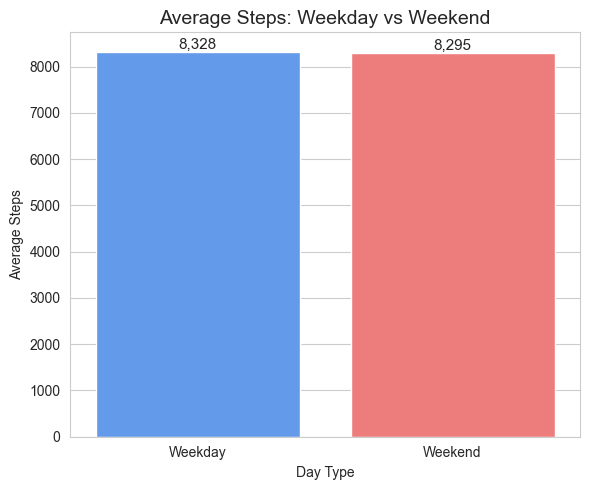

In [38]:
avg_steps = activity.groupby('DayType')['TotalSteps'].mean().reset_index()

print("=== Average Steps: Weekday vs Weekend ===")
print(avg_steps)

plt.figure(figsize=(6, 5))
bars = sns.barplot(data=avg_steps,
                   x='DayType',
                   y='TotalSteps',
                   palette=['#4d96ff', '#ff6b6b'])

# Add exact numbers on top of each bar
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():,.0f}',
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='bottom', fontsize=11)

plt.title('Average Steps: Weekday vs Weekend', fontsize=14)
plt.xlabel('Day Type')
plt.ylabel('Average Steps')
plt.tight_layout()
plt.savefig('weekday_vs_weekend.png', dpi=150)
plt.show()

# Analysis-6 — Smart Device Usage Frequency

Average days device worn : 26.2 days
Total days in dataset    : 31 days
High engagement users    : 21 (wore 25+ days)
Low engagement users     : 1 (wore fewer than 15 days)


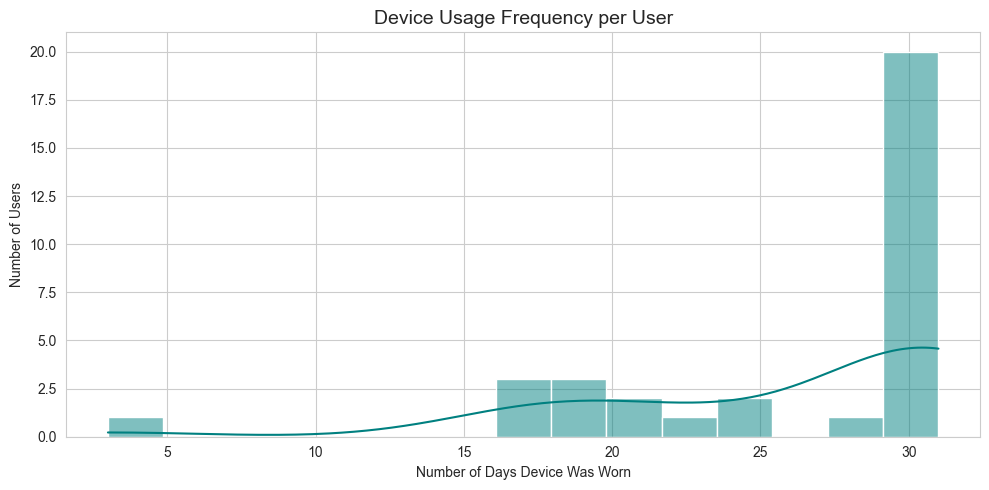

In [39]:
# Count how many days each user logged activity
usage = activity.groupby('Id')['ActivityDate'].count().reset_index()
usage.columns = ['Id', 'DaysWorn']

avg_days  = usage['DaysWorn'].mean()
max_days  = activity['ActivityDate'].nunique()
high_eng  = (usage['DaysWorn'] >= 25).sum()
low_eng   = (usage['DaysWorn'] < 15).sum()

print(f"Average days device worn : {avg_days:.1f} days")
print(f"Total days in dataset    : {max_days} days")
print(f"High engagement users    : {high_eng} (wore 25+ days)")
print(f"Low engagement users     : {low_eng} (wore fewer than 15 days)")

plt.figure()
sns.histplot(usage['DaysWorn'], bins=15, color='teal', kde=True)
plt.title('Device Usage Frequency per User', fontsize=14)
plt.xlabel('Number of Days Device Was Worn')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig('device_usage.png', dpi=150)
plt.show()

# Analysis-7 Average sleep hours per user

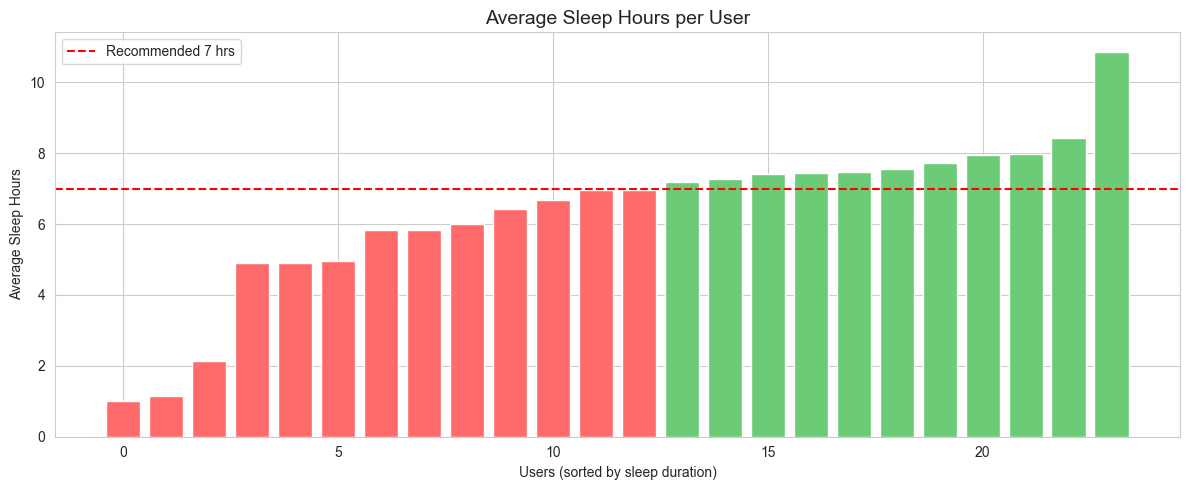

Users averaging under 7 hrs sleep: 13 out of 24


In [40]:
sleep_per_user = sleep_logged.groupby('Id')['SleepHours'].mean().reset_index()
sleep_per_user.columns = ['Id', 'AvgSleepHours']
sleep_per_user = sleep_per_user.sort_values('AvgSleepHours')

colors = ['#ff6b6b' if h < 7 else '#6bcb77' for h in sleep_per_user['AvgSleepHours']]

plt.figure(figsize=(12, 5))
plt.bar(range(len(sleep_per_user)), sleep_per_user['AvgSleepHours'], color=colors)
plt.axhline(y=7, color='red', linestyle='--', label='Recommended 7 hrs')
plt.title('Average Sleep Hours per User', fontsize=14)
plt.xlabel('Users (sorted by sleep duration)')
plt.ylabel('Average Sleep Hours')
plt.legend()
plt.tight_layout()
plt.savefig('sleep_per_user.png', dpi=150)
plt.show()

under_7_users = (sleep_per_user['AvgSleepHours'] < 7).sum()
print(f"Users averaging under 7 hrs sleep: {under_7_users} out of {len(sleep_per_user)}")

# Analysis-8 — Steps vs Sleep correlation

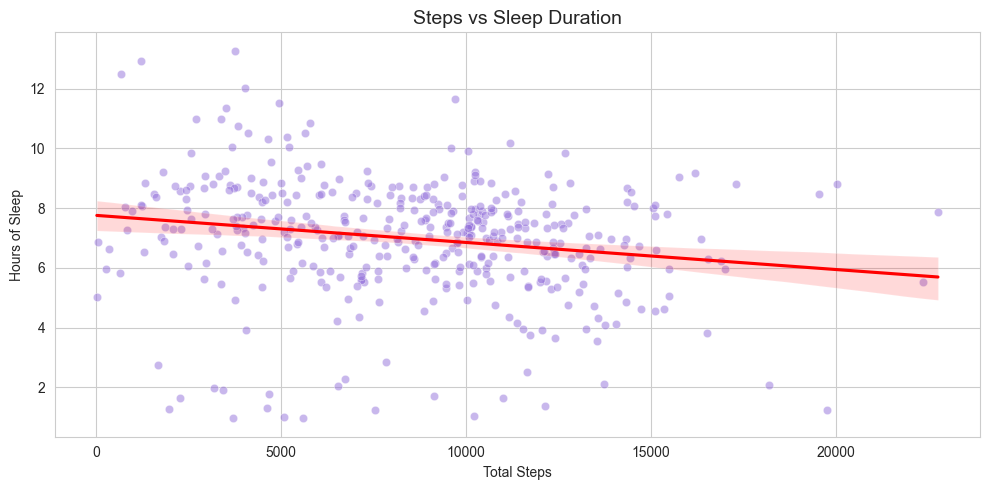

Correlation between Steps and Sleep: -0.19
No meaningful correlation between steps and sleep


In [41]:

# Does more activity = better sleep?
merged = activity[activity['TotalMinutesAsleep'] > 0].copy()
merged['SleepHours'] = merged['TotalMinutesAsleep'] / 60

plt.figure()
sns.scatterplot(data=merged, x='TotalSteps', y='SleepHours', alpha=0.5, color='mediumpurple')
sns.regplot(data=merged, x='TotalSteps', y='SleepHours', scatter=False, color='red')
plt.title('Steps vs Sleep Duration', fontsize=14)
plt.xlabel('Total Steps')
plt.ylabel('Hours of Sleep')
plt.tight_layout()
plt.savefig('steps_vs_sleep.png', dpi=150)
plt.show()

corr2 = merged['TotalSteps'].corr(merged['SleepHours'])
print(f"Correlation between Steps and Sleep: {corr2:.2f}")

if corr2 > 0.5:
    print("Strong positive correlation — more steps = more sleep")
elif corr2 > 0.2:
    print("Weak positive correlation — slight trend but not strong")
elif corr2 < -0.2:
    print("Negative correlation — more steps = less sleep")
else:
    print("No meaningful correlation between steps and sleep")



# Sedentary Hours Distribution

Average sedentary hours per day: 15.9 hrs


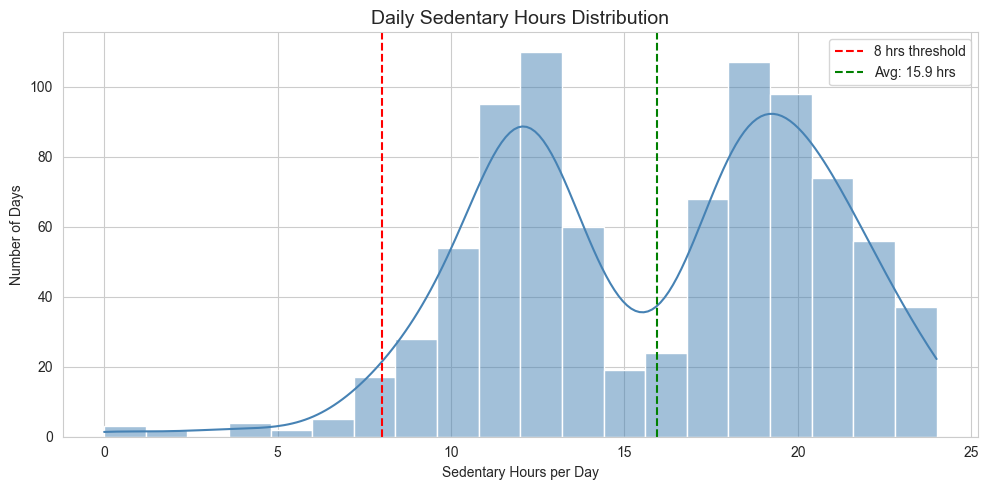

In [42]:
avg_sed = activity['SedentaryHours'].mean()
print(f"Average sedentary hours per day: {avg_sed:.1f} hrs")

plt.figure()
sns.histplot(activity['SedentaryHours'], bins=20, color='steelblue', kde=True)
plt.axvline(x=8,       color='red',    linestyle='--', label='8 hrs threshold')
plt.axvline(x=avg_sed, color='green',  linestyle='--', label=f'Avg: {avg_sed:.1f} hrs')
plt.title('Daily Sedentary Hours Distribution', fontsize=14)
plt.xlabel('Sedentary Hours per Day')
plt.ylabel('Number of Days')
plt.legend()
plt.tight_layout()
plt.savefig('sedentary_hours.png', dpi=150)
plt.show()

#  Weight & BMI Analysis

C:\Users\Harika challa\AppData\Local\Temp\ipykernel_2696\2737148073.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  weight['ActivityDateTime'] = pd.to_datetime(weight['ActivityDateTime'], infer_datetime_format=True)
C:\Users\Harika challa\AppData\Local\Temp\ipykernel_2696\2737148073.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weight['ActivityDateTime'] = pd.to_datetime(weight['ActivityDateTime'], infer_datetime_format=True)


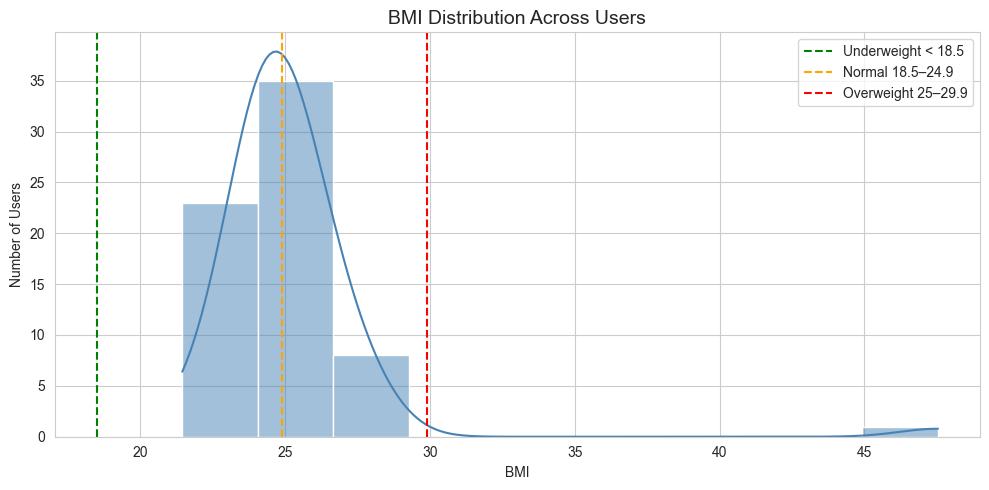

Average BMI: 25.2
Total users with weight data: 8

BMI Category Distribution:
BMICategory
Normal        34
Overweight    32
Obese          1
Name: count, dtype: int64


In [43]:
weight['ActivityDateTime'] = pd.to_datetime(weight['ActivityDateTime'], infer_datetime_format=True)
weight['Date'] = weight['ActivityDateTime'].dt.date

# BMI Distribution
plt.figure()
sns.histplot(weight['BMI'], bins=10, color='steelblue', kde=True)
plt.axvline(x=18.5, color='green',  linestyle='--', label='Underweight < 18.5')
plt.axvline(x=24.9, color='orange', linestyle='--', label='Normal 18.5–24.9')
plt.axvline(x=29.9, color='red',    linestyle='--', label='Overweight 25–29.9')
plt.title('BMI Distribution Across Users', fontsize=14)
plt.xlabel('BMI')
plt.ylabel('Number of Users')
plt.legend()
plt.tight_layout()
plt.savefig('bmi_distribution.png', dpi=150)
plt.show()

avg_bmi = weight['BMI'].mean()
print(f"Average BMI: {avg_bmi:.1f}")
print(f"Total users with weight data: {weight['Id'].nunique()}")

# BMI Category per User
weight['BMICategory'] = weight['BMI'].apply(
    lambda x: 'Underweight' if x < 18.5
         else 'Normal'      if x < 24.9
         else 'Overweight'  if x < 29.9
         else 'Obese')

print("\nBMI Category Distribution:")
print(weight['BMICategory'].value_counts())

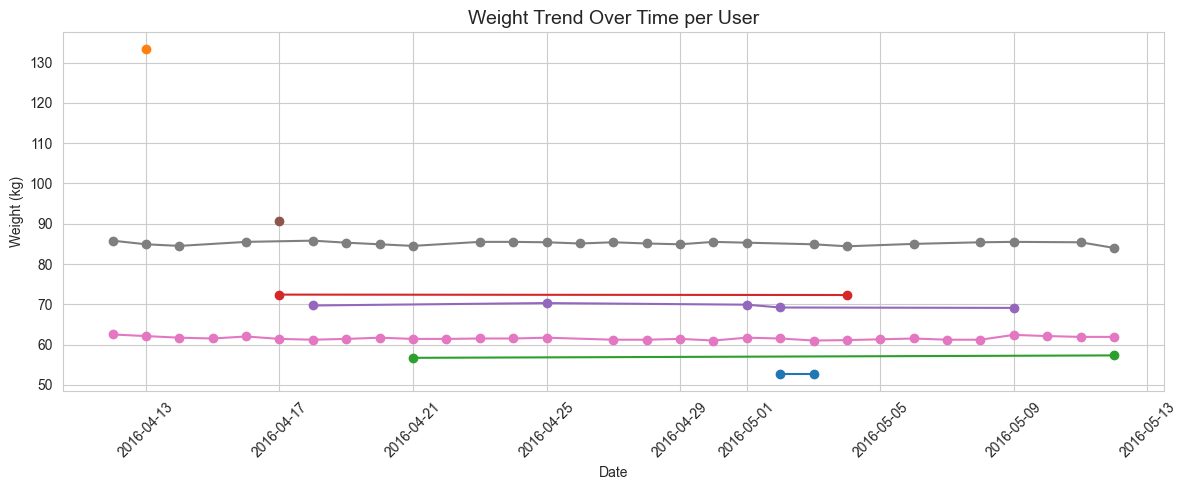

In [44]:
# Weight Trend Over Time per User
plt.figure(figsize=(12, 5))
for user_id in weight['Id'].unique():
    user_data = weight[weight['Id'] == user_id]
    plt.plot(user_data['Date'], user_data['WeightKg'], marker='o', label=str(user_id))
plt.title('Weight Trend Over Time per User', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Weight (kg)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('weight_trend.png', dpi=150)
plt.show()

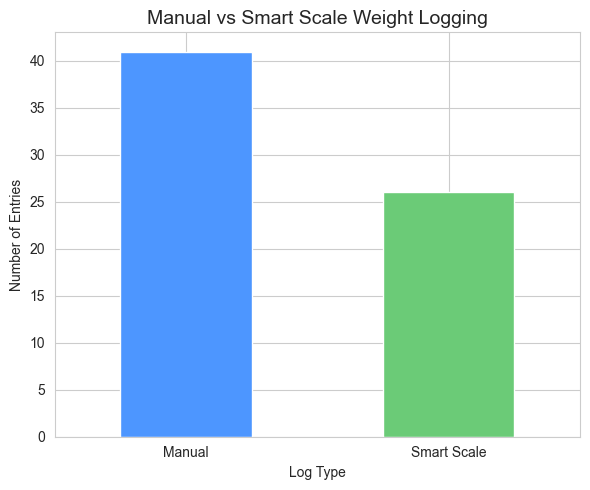

In [45]:
# Manual vs Smart Scale Logging
log_type = weight['IsManualReport'].value_counts()
log_type.index = ['Manual' if x == 1 else 'Smart Scale' for x in log_type.index]
plt.figure(figsize=(6, 5))
log_type.plot(kind='bar', color=['#4d96ff', '#6bcb77'], edgecolor='white')
plt.title('Manual vs Smart Scale Weight Logging', fontsize=14)
plt.xlabel('Log Type')
plt.ylabel('Number of Entries')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('weight_log_type.png', dpi=150)
plt.show()

# Heart Rate Intensity Analysis

C:\Users\Harika challa\AppData\Local\Temp\ipykernel_2696\3652729347.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  heartrate['ActivityDateTime'] = pd.to_datetime(heartrate['ActivityDateTime'],


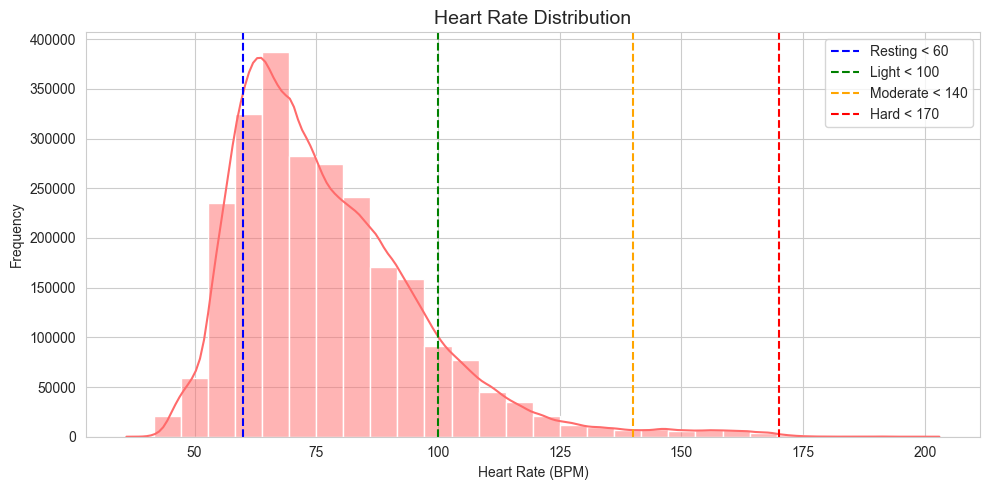

Average Heart Rate : 77.3 BPM
Max Heart Rate     : 203 BPM
Min Heart Rate     : 36 BPM


In [54]:
# ── Heart Rate Intensity Analysis ─────────────────────────
heartrate['ActivityDateTime'] = pd.to_datetime(heartrate['ActivityDateTime'],
                                                infer_datetime_format=True)
heartrate['Hour']      = heartrate['ActivityDateTime'].dt.hour
heartrate['DayOfWeek'] = heartrate['ActivityDateTime'].dt.day_name()
heartrate['Date']      = heartrate['ActivityDateTime'].dt.date

# Heart Rate Zone Classification
def hr_zone(hr):
    if hr < 60:   return 'Resting'
    elif hr < 100: return 'Light'
    elif hr < 140: return 'Moderate'
    elif hr < 170: return 'Hard'
    else:          return 'Maximum'

heartrate['HRZone'] = heartrate['HeartRate'].apply(hr_zone)

# Heart Rate Distribution
plt.figure()
sns.histplot(heartrate['HeartRate'], bins=30, color='#ff6b6b', kde=True)
plt.axvline(x=60,  color='blue',   linestyle='--', label='Resting < 60')
plt.axvline(x=100, color='green',  linestyle='--', label='Light < 100')
plt.axvline(x=140, color='orange', linestyle='--', label='Moderate < 140')
plt.axvline(x=170, color='red',    linestyle='--', label='Hard < 170')
plt.title('Heart Rate Distribution', fontsize=14)
plt.xlabel('Heart Rate (BPM)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('heartrate_distribution.png', dpi=150)
plt.show()

avg_hr = heartrate['HeartRate'].mean()
print(f"Average Heart Rate : {avg_hr:.1f} BPM")
print(f"Max Heart Rate     : {heartrate['HeartRate'].max()} BPM")
print(f"Min Heart Rate     : {heartrate['HeartRate'].min()} BPM")



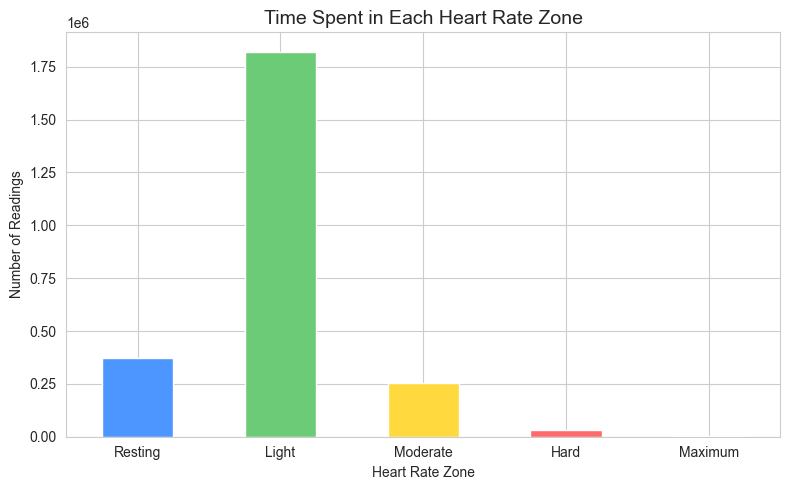

In [55]:
# HR Zone Distribution
zone_counts = heartrate['HRZone'].value_counts()
zone_order  = ['Resting', 'Light', 'Moderate', 'Hard', 'Maximum']
zone_counts = zone_counts.reindex(zone_order)

plt.figure(figsize=(8, 5))
zone_counts.plot(kind='bar',
                 color=['#4d96ff','#6bcb77','#ffd93d','#ff6b6b','#c0392b'],
                 edgecolor='white')
plt.title('Time Spent in Each Heart Rate Zone', fontsize=14)
plt.xlabel('Heart Rate Zone')
plt.ylabel('Number of Readings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('hr_zones.png', dpi=150)
plt.show()

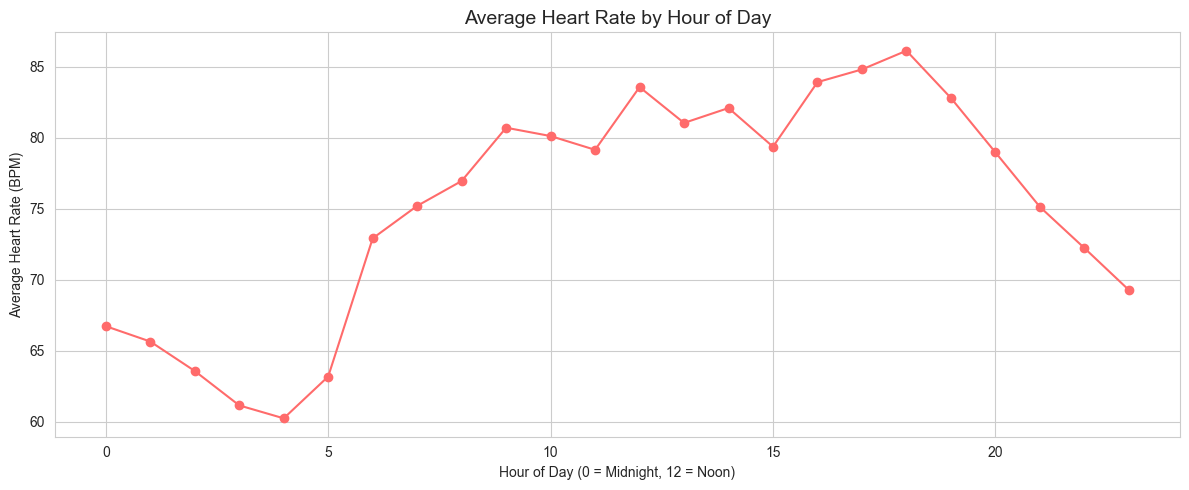

In [56]:
# Average Heart Rate by Hour of Day
avg_hr_hour = heartrate.groupby('Hour')['HeartRate'].mean()
plt.figure(figsize=(12, 5))
avg_hr_hour.plot(kind='line', color='#ff6b6b', marker='o')
plt.title('Average Heart Rate by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Average Heart Rate (BPM)')
plt.tight_layout()
plt.savefig('heartrate_by_hour.png', dpi=150)
plt.show()